In [1]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#!pip install imbalanced-learn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

In [2]:
# Step 2: Load Dataset

# Replace with your file path
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())
print(df.shape)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

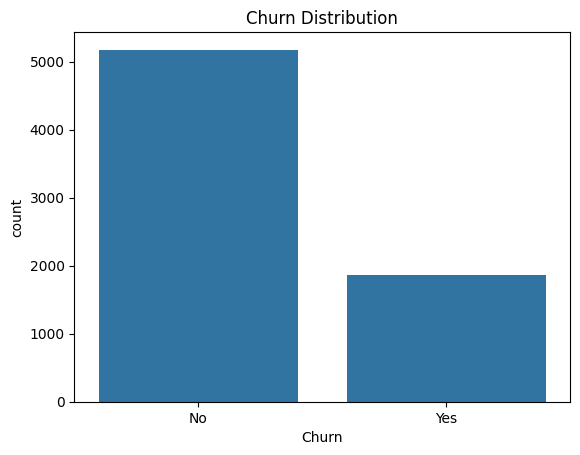

In [3]:
# Step 3: Exploratory Data Analysis (EDA)

print(df.info())
print(df.describe())

# Target variable distribution
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [4]:
# Step 4: Data Cleaning

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Handle missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Drop customerID (not useful)
df.drop("customerID", axis=1, inplace=True)

C:\Users\hamza\AppData\Local\Temp\ipykernel_10672\834885843.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [5]:

# Step 5: Encoding Categorical Variables (ECV)

le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

C:\Users\hamza\AppData\Local\Temp\ipykernel_10672\1712188251.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [6]:
# Step 6: Check Imbalance

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [7]:
# Step 7: Feature & Target Split

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [8]:
# Step 8: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [9]:
# Step 9: Missing Values Handling

X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_test.median())

In [10]:
# Step 10: Handle Imbalance using SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(y_train_sm.value_counts())

Churn
0    3880
1    3880
Name: count, dtype: int64


In [11]:
# Step 11: Feature Scaling

scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

In [12]:
# Step 12: Model Training & Evaluation function

results = {}

def evaluate_model(name, model):
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

In [13]:
# Step 13: Logistic Regression

lr = LogisticRegression()
evaluate_model("Logistic Regression", lr)


Logistic Regression
Accuracy: 0.7592277115275412
Confusion Matrix:
 [[996 298]
 [126 341]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.77      0.82      1294
           1       0.53      0.73      0.62       467

    accuracy                           0.76      1761
   macro avg       0.71      0.75      0.72      1761
weighted avg       0.79      0.76      0.77      1761



In [14]:
# Step 14: Naive Bayes (NB)

nb = GaussianNB()
evaluate_model("Naive Bayes", nb)


Naive Bayes
Accuracy: 0.7387847813742192
Confusion Matrix:
 [[963 331]
 [129 338]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.74      0.81      1294
           1       0.51      0.72      0.60       467

    accuracy                           0.74      1761
   macro avg       0.69      0.73      0.70      1761
weighted avg       0.78      0.74      0.75      1761



In [15]:
# Step 15: K-Nearest Neighbors (KNN)

knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model("KNN", knn)


KNN
Accuracy: 0.7098239636570131
Confusion Matrix:
 [[937 357]
 [154 313]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.72      0.79      1294
           1       0.47      0.67      0.55       467

    accuracy                           0.71      1761
   macro avg       0.66      0.70      0.67      1761
weighted avg       0.75      0.71      0.72      1761



In [16]:
# Step 16: Support Vector Classifier (SVC)

svc = SVC(probability=True)
evaluate_model("SVC", svc)


SVC
Accuracy: 0.7739920499716071
Confusion Matrix:
 [[1064  230]
 [ 168  299]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84      1294
           1       0.57      0.64      0.60       467

    accuracy                           0.77      1761
   macro avg       0.71      0.73      0.72      1761
weighted avg       0.78      0.77      0.78      1761



In [17]:
# Step 17: Decision Tree

dt = DecisionTreeClassifier(max_depth=6, random_state=42)
evaluate_model("Decision Tree", dt)


Decision Tree
Accuracy: 0.75809199318569
Confusion Matrix:
 [[1023  271]
 [ 155  312]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.79      0.83      1294
           1       0.54      0.67      0.59       467

    accuracy                           0.76      1761
   macro avg       0.70      0.73      0.71      1761
weighted avg       0.78      0.76      0.77      1761



                     Accuracy
SVC                  0.773992
Logistic Regression  0.759228
Decision Tree        0.758092
Naive Bayes          0.738785
KNN                  0.709824


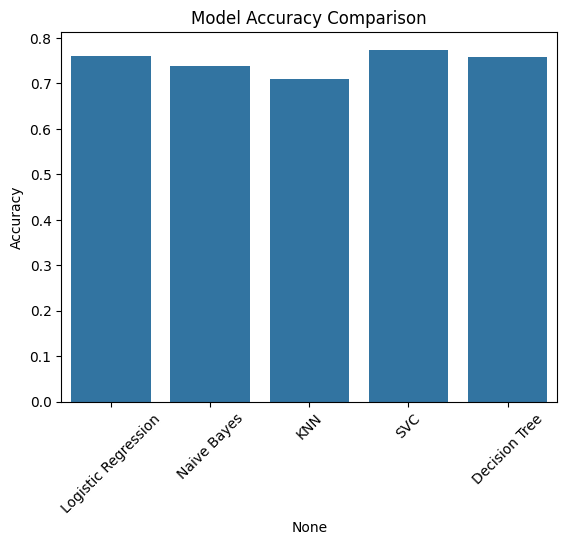

In [18]:
# Step 18: Model Comparison

results_df = pd.DataFrame.from_dict(results, orient="index", columns=["Accuracy"])
print(results_df.sort_values(by="Accuracy", ascending=False))

sns.barplot(x=results_df.index, y="Accuracy", data=results_df)
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()

In [19]:
# Step 19: Best Model Selection

best_model = results_df["Accuracy"].idxmax()
print("Best Model:", best_model)

Best Model: SVC
